# Phase 3: Risk Metrics


## 1. Imports

In [1]:
import sys 
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root))

##2. Load Processed Data

In [2]:
data_path = project_root / "data" / "processed" / "daily_returns.csv"

daily_returns = pd.read_csv(
    data_path,
    index_col=0,
    parse_dates=True
)

daily_returns.head()

,JPM,SPY,TLT,GLD,JNJ,AAPL,XOM,KO
Date,,,,,,,,
2016-01-05,0.001729,0.001691,-0.004034,0.002819,0.004180,-0.025059,0.008520,0.003538
2016-01-06,-0.014436,-0.012614,0.013475,0.014441,-0.005055,-0.019570,-0.008320,-0.005406
2016-01-07,-0.040439,-0.023991,0.001795,0.014140,-0.011654,-0.042205,-0.016006,-0.016540
2016-01-08,-0.022399,-0.010977,0.004479,-0.004428,-0.010684,0.005288,-0.020202,-0.002643
2016-01-11,-0.001528,0.000990,-0.010944,-0.008895,-0.006010,0.016192,-0.013389,0.001686


##3. Daily Volatility

In [3]:
daily_volatility = daily_returns.std()

daily_volatility.sort_values(ascending=False)

AAPL    0.018216
XOM     0.017608
JPM     0.017263
JNJ     0.011643
KO      0.011446
SPY     0.011218
GLD     0.010233
TLT     0.009290
dtype: float64

##4. Annualized Volatility

In [4]:
annual_volatility = daily_volatility * np.sqrt(252)

annual_volatility.sort_values(ascending= False)

AAPL    0.289163
XOM     0.279524
JPM     0.274040
JNJ     0.184832
KO      0.181695
SPY     0.178086
GLD     0.162449
TLT     0.147469
dtype: float64

In [5]:
annual_volatility_percent = annual_volatility * 100
annual_volatility_percent.sort_values(ascending = False)

AAPL    28.916273
XOM     27.952358
JPM     27.404048
JNJ     18.483191
KO      18.169483
SPY     17.808601
GLD     16.244940
TLT     14.746890
dtype: float64

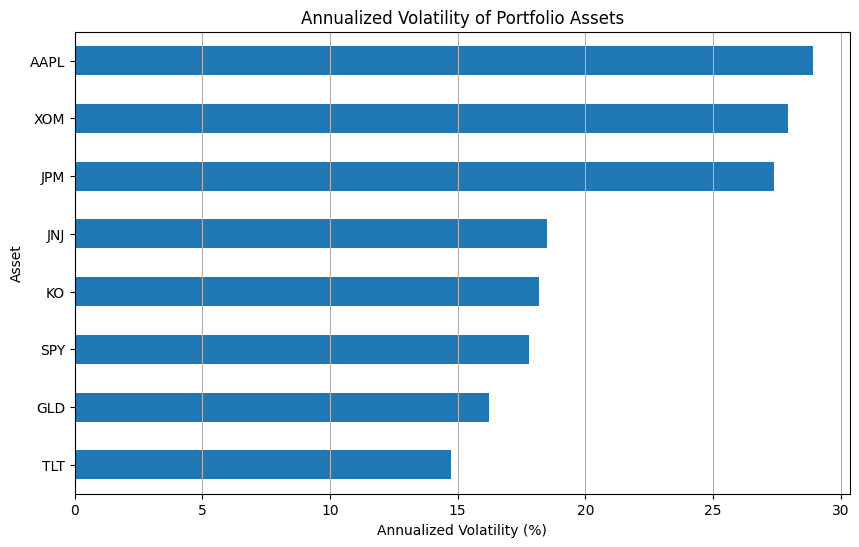

In [6]:
annual_volatility_percent.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Annualized Volatility of Portfolio Assets")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Asset")

plt.grid(axis="x")
plt.show()

##5. Correlation Analysis

In [7]:
correlation_matrix = daily_returns.corr()

correlation_matrix

,JPM,SPY,TLT,GLD,JNJ,AAPL,XOM,KO
JPM,1.000000,0.701697,-0.307057,-0.063800,0.329744,0.407726,0.503279,0.385279
SPY,0.701697,1.000000,-0.155990,0.076342,0.428062,0.741368,0.486361,0.491976
TLT,-0.307057,-0.155990,1.000000,0.259906,-0.086755,-0.092116,-0.237250,-0.071798
GLD,-0.063800,0.076342,0.259906,1.000000,0.043699,0.035133,0.036421,0.044607
JNJ,0.329744,0.428062,-0.086755,0.043699,1.000000,0.289434,0.283459,0.494959
AAPL,0.407726,0.741368,-0.092116,0.035133,0.289434,1.000000,0.277226,0.323400
XOM,0.503279,0.486361,-0.237250,0.036421,0.283459,0.277226,1.000000,0.355110
KO,0.385279,0.491976,-0.071798,0.044607,0.494959,0.323400,0.355110,1.000000


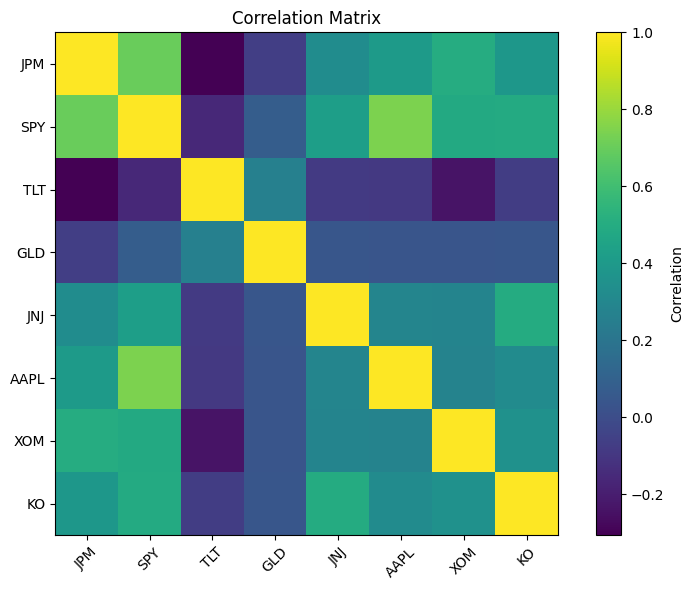

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=45)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

##6. Portfolio Volatility

In [9]:
weights = np.array([1/8] * 8)

print(weights)
print(weights.sum())

[0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
1.0


In [10]:
portfolio_returns = daily_returns.dot(weights)

portfolio_returns.head()

Date
2016-01-05   -0.000827
2016-01-06   -0.004686
2016-01-07   -0.016863
2016-01-08   -0.007696
2016-01-11   -0.002737
dtype: float64

In [11]:
portfolio_daily_volatility = portfolio_returns.std()

print(portfolio_daily_volatility)

0.00792544620251536


In [12]:
portfolio_annual_volatility = portfolio_daily_volatility * np.sqrt(252)

print(f"Portfolio Annual Volatility: {portfolio_annual_volatility:.2%}")


Portfolio Annual Volatility: 12.58%


##7. Beta

In [13]:
market_returns = daily_returns["SPY"]

In [14]:
betas = {}

In [15]:
for asset in daily_returns.columns:
    covariance = daily_returns[asset].cov(market_returns)
    market_variance = market_returns.var()

    beta = covariance / market_variance

    betas[asset] = beta

In [16]:
beta_series = pd.Series(betas)

beta_series.sort_values(ascending=False)

AAPL    1.203777
JPM     1.079778
SPY     1.000000
XOM     0.763391
KO      0.501946
JNJ     0.444277
GLD     0.069639
TLT    -0.129172
dtype: float64